In [132]:
import seaborn as sns

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
}
sns.set_theme(context="notebook", style="ticks", rc=custom_params)

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from typing import List, Tuple
import os
import json
import re
from matplotlib.cm import viridis
from matplotlib.colors import Normalize, LogNorm

# Extraction functions

In [134]:
def parse_config(path: str) -> Tuple[List[np.ndarray], int]:
    """
    Parses .config files containing trajectories of particlrs in suspension at each time step.
    Arguments :
        path, the path to the config file.
    Returns :
        frames, lists of arrays of positions per time step.
        n_expected, the number of expected separate trajectorires.
    """
    frames: List[np.ndarray] = []
    n_expected = None

    with open(path, "r", encoding="utf-8") as f:
        lines = (ln.strip() for ln in f)
        while True:
            for ln in lines:
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) == 1 and parts[0].lstrip("-").isdigit():
                    n = int(parts[0])
                    if n <= 0:
                        raise ValueError(f"Invalid particle count: {n}")
                    if n_expected is None:
                        n_expected = n
                    elif n_expected != n:
                        raise ValueError(
                            f"Inconsistent particle count: {n} (expected {n_expected})"
                        )
                    break
                else:
                    raise ValueError(f"Expected particle count line, got: {ln}")
            else:
                break

            xyz = []
            for _ in range(n):
                try:
                    ln = next(lines).strip()
                except StopIteration:
                    raise ValueError("Unexpected EOF inside a timestep.")
                vals = ln.split()
                x, y, z = map(float, vals[:3])
                xyz.append((x, y, z))
            frames.append(np.asarray(xyz, dtype=float))
    return frames, n_expected


def frames_to_trajectories(frames: List[np.ndarray]) -> List[np.ndarray]:
    """
    Generates full trajectories from the frames.
    frames: list of arrays shaped (n,3) for each timestep.
    return: list of trajectories, each shaped (T,3), one per particle.
    """
    if not frames:
        raise ValueError("Where frames ???")
    n = frames[0].shape[0]
    arr = np.stack(frames, axis=0)  # (T, n, 3)
    return [arr[:, i, :] for i in range(n)]  # N [(T,3)]

In [135]:
def compute_average_msd(signal_list, dt):
    """Returns the MSD avg and std of a whole component."""
    lag_steps = np.hstack(
        [np.arange(10**i, 10 ** (i + 1), 10**i) for i in range(8)]
    ).astype(int)
    if lag_steps.size == 0:
        return (
            np.array([], dtype=float),
            np.array([], dtype=float),
            np.array([], dtype=float),
        )

    def msd_fixed(x, lags):
        x = np.asarray(x, dtype=float)
        msd = np.empty(len(lags), dtype=float)
        for n, lag in enumerate(lags):
            # mean over valid pairs
            diffs = x[lag:] - x[:-lag]
            msd[n] = np.nanstd(diffs) ** 2
        return msd

    all_msd = [msd_fixed(sig, lag_steps) for sig in signal_list]
    all_msd = np.vstack(all_msd)
    msd_avg = np.nanmean(all_msd, axis=0)
    msd_std = np.nanstd(all_msd, axis=0)
    return lag_steps * dt, msd_avg, msd_std

In [136]:
def collective_and_relative(trajs: List[np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    if len(trajs) != 2:
        raise ValueError(f"Expected 2 trajectories, got {len(trajs)}.")
    x0, x1 = trajs[0], trajs[1]
    if x0.shape != x1.shape:
        raise ValueError(f"Trajectory shape mismatch: {x0.shape} vs {x1.shape}")
    Xc = x0 + x1
    Xr = x1 - x0
    return Xc, Xr


def displacements(arr: np.ndarray, lag: int) -> np.ndarray:
    T = arr.shape[0]
    return arr[lag:] - arr[:-lag]


def default_Deff_collective_relative(
    D0: float,
) -> Tuple[float, float]:
    D_c = 2.0 * D0
    D_r = 2.0 * D0
    return D_c, D_r


def diffusion_edges(
    lag: int, dt: float, D_eff: float, bins: int, n_sigma: float
) -> np.ndarray:
    DeltaT = lag * dt
    sigma = np.sqrt(2.0 * D_eff * DeltaT)
    L = n_sigma * sigma
    if not np.isfinite(L) or L == 0.0:
        L = 1.0
    return np.linspace(-L, +L, bins + 1)


def histogram_from_edges(samples_1d: np.ndarray, edges: np.ndarray) -> np.ndarray:
    hist, _ = np.histogram(samples_1d, bins=edges, density=True)
    return hist


from pathlib import Path
from typing import List, Tuple, Dict, Iterable


def iter_case_dirs(base_dir: str = "pairs") -> Iterable[Path]:
    base = Path(base_dir)
    if not base.exists():
        raise FileNotFoundError(f"Base directory '{base_dir}' not found.")
    for p in sorted(base.iterdir()):
        if p.is_dir() and p.name.startswith("h=") and "_d=" in p.name:
            yield p


def list_config_files(
    case_dir: Path, trajectories_subdir: str = "trajectories"
) -> List[Path]:
    tdir = case_dir / trajectories_subdir
    if not tdir.exists():
        return []
    return sorted(tdir.glob("*.config"))

In [ ]:
def analyze_case(
    case_dir: Path,
    dt: float,
    lags: List[int],
    D0: float,
    axis: int = 0,
    bins: int = 200,
    n_sigma: float = 6.0,
    trajectories_subdir: str = "trajectories",
    out_name: str = "histograms_collective_relative.npz",
) -> Path:

    cfg_files = list_config_files(case_dir, trajectories_subdir=trajectories_subdir)

    D_collective, D_relative = default_Deff_collective_relative(D0)

    pooled: Dict[str, Dict[int, List[np.ndarray]]] = {
        "dc": {lag: [] for lag in lags},
        "dr": {lag: [] for lag in lags},
    }

    for cfg in cfg_files:
        frames, n = parse_config(str(cfg))

        trajs = frames_to_trajectories(frames)
        Xc, Xr = collective_and_relative(trajs)

        for lag in lags:
            dXc = displacements(Xc, lag)
            dXr = displacements(Xr, lag)
            if dXc.shape[0] == 0 or dXr.shape[0] == 0:
                continue
            pooled["dc"][lag].append(dXc[:, axis])
            pooled["dr"][lag].append(dXr[:, axis])

    pooled_concat: Dict[str, Dict[int, np.ndarray]] = {"dc": {}, "dr": {}}
    for key in ("dc", "dr"):
        for lag in lags:
            if pooled[key][lag]:
                pooled_concat[key][lag] = np.concatenate(pooled[key][lag], axis=0)
            else:
                pooled_concat[key][lag] = np.empty((0,), dtype=float)

    nL = len(lags)
    edges_c = np.zeros((nL, bins + 1), dtype=float)
    edges_r = np.zeros((nL, bins + 1), dtype=float)
    hist_c = np.zeros((nL, bins), dtype=float)
    hist_r = np.zeros((nL, bins), dtype=float)

    for i, lag in enumerate(lags):
        e_c = diffusion_edges(lag, dt, D_collective, bins=bins, n_sigma=n_sigma)
        e_r = diffusion_edges(lag, dt, D_relative, bins=bins, n_sigma=n_sigma)

        edges_c[i, :] = e_c
        edges_r[i, :] = e_r

        samp_c = pooled_concat["dc"][lag]
        samp_r = pooled_concat["dr"][lag]

        hist_c[i, :] = histogram_from_edges(samp_c, e_c)
        hist_r[i, :] = histogram_from_edges(samp_r, e_r)

    out_path = case_dir / out_name
    np.savez_compressed(
        out_path,
        lags=np.asarray(lags, dtype=int),
        dt=float(dt),
        axis=int(axis),
        bins=int(bins),
        n_sigma=float(n_sigma),
        D0=float(D0),
        D_collective=float(D_collective),
        D_relative=float(D_relative),
        edges_collective=edges_c,
        edges_relative=edges_r,
        hist_collective=hist_c,
        hist_relative=hist_r,
    )

    return out_path


def analyze_all_cases(
    base_dir: str,
    dt: float,
    D0: float,
    lags: List[int],
    axis: int = 0,
    bins: int = 31,
    n_sigma: float = 6.0,
):
    for case_dir in iter_case_dirs(base_dir):
        try:
            out = analyze_case(
                case_dir=case_dir,
                dt=dt,
                lags=lags,
                D0=D0,
                axis=axis,
                bins=bins,
                n_sigma=n_sigma,
            )
            print(f"{case_dir}: wrote {out.name}")
        except Exception as e:
            print(f"{case_dir}: FAILED: {e}")

In [ ]:
base_dir = "pairs"


lags = [1, 2, 5, 10, 20, 50, 100, 200, 500]


axis = 0


dt = 1e-3
D0 = 0.25


bins = 31
n_sigma = 3.0


analyze_all_cases(
    base_dir=base_dir, dt=dt, D0=D0, lags=lags, axis=axis, bins=bins, n_sigma=n_sigma
)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.63384346e-02
 8.98613902e-02 2.28738084e-01 1.34792085e+00 4.33785438e+00
 1.08078745e+01 1.96551368e+01 2.86412758e+01 3.26686999e+01
 2.86821219e+01 1.96959829e+01 1.09222435e+01 4.41137734e+00
 1.50313598e+00 3.43107126e-01 3.26768692e-02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.05782291  0.2659854   0.95986034  3.0993081
  7.2567755  14.08566144 20.07033287 23.23324617 19.96046934 14.48463954
  7.24521092  3.46359245  1.03503013  0.24863852  0.0636052   0.
  0.          0.          0.          0.          0.          0.
  0.        ]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 3.66805727e-03 1.46722291e-02
 2.93444581e-02 1.65062577e-01 5.79553048e-01 1.89

frames, n_expected = parse_config(
    "/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/agim_project/pairs/h=0.55um_d=0.55um/trajectories/traj_0000.config"
)
traj = frames_to_trajectories(frames)

plt.figure()
for i, tr in enumerate(traj):
    plt.plot(tr[:, 0], alpha=0.7, label=f"x{i}")
    plt.plot(tr[:, 1], alpha=0.7, label=f"y{i}")
    plt.plot(tr[:, 2], alpha=0.7, label=f"z{i}")


plt.xlabel("Time step")
plt.legend()
plt.show()

Lookimg googd

# computing the MSD per z bin

In [139]:
def get_component_signal(tr, comp):
    if isinstance(tr, dict):
        return np.asarray(tr[comp], dtype=float)
    comp_idx = {"x": 0, "y": 1, "z": 2}[comp]
    tr = np.asarray(tr)
    if tr.ndim == 2 and tr.shape[1] >= comp_idx + 1:
        return tr[:, comp_idx].astype(float)
    raise ValueError("Unrecognized trajectory format for get_component_signal func")


def plot_all_segments(signals, comp, dt):
    plt.figure()
    for seg in signals:
        y = get_component_signal(seg, comp).astype(float)
        t = np.arange(len(y)) * dt
        plt.plot(t, y, alpha=0.8)

    plt.xlabel("Time (s)")
    plt.ylabel(f"{comp}(t)")
    plt.tight_layout()
    plt.show()

Plotter

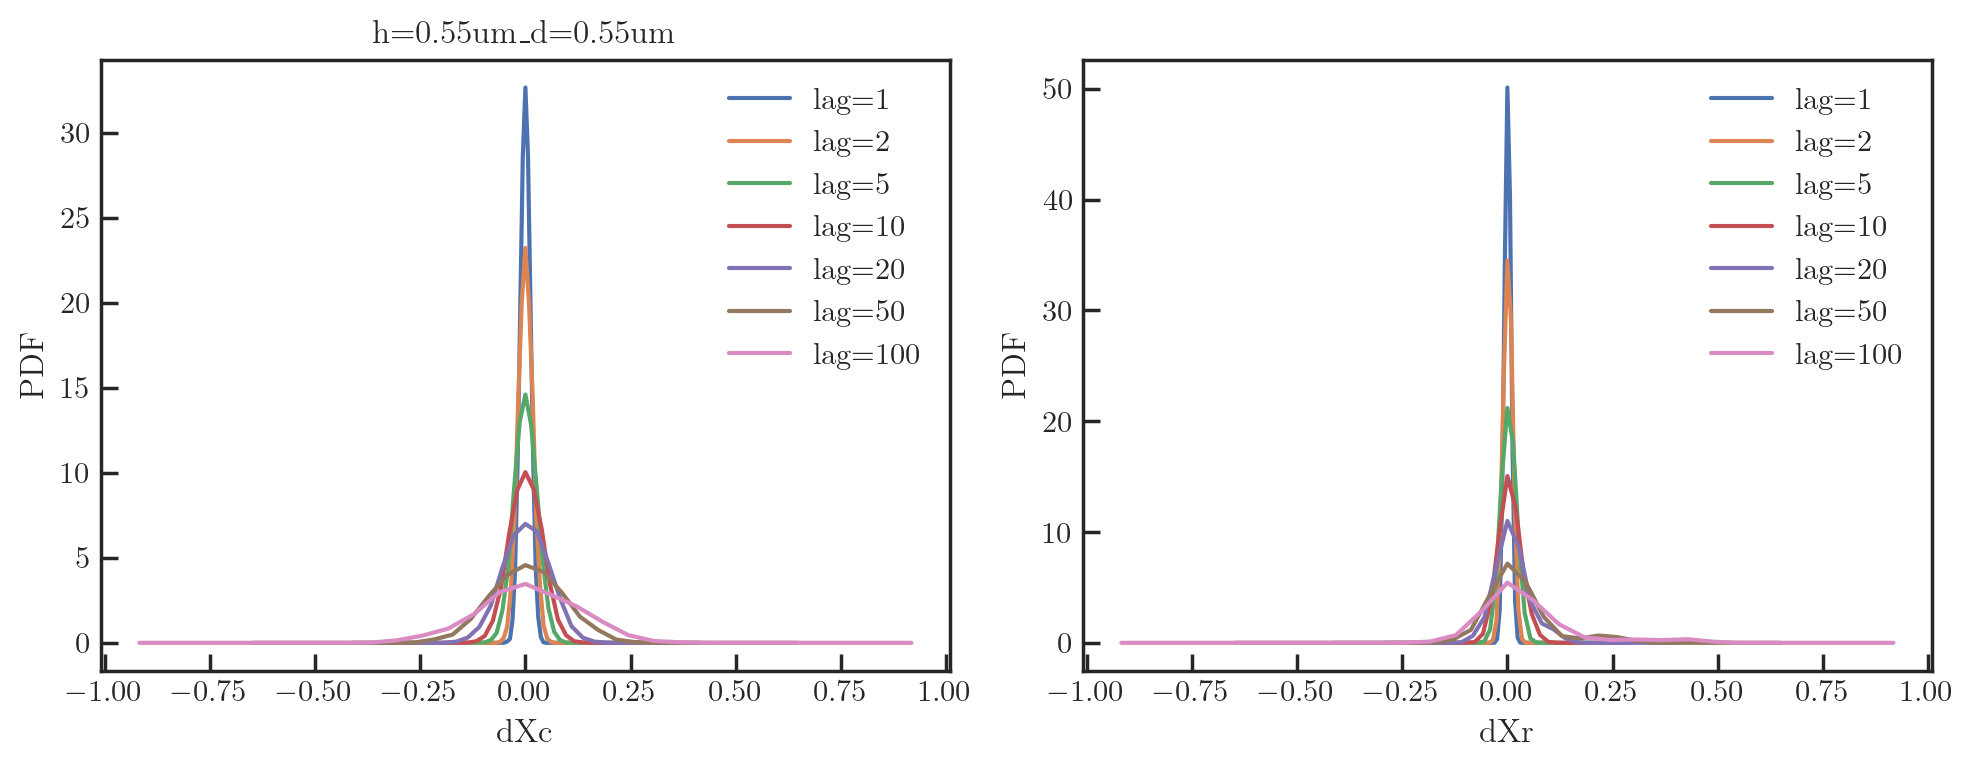

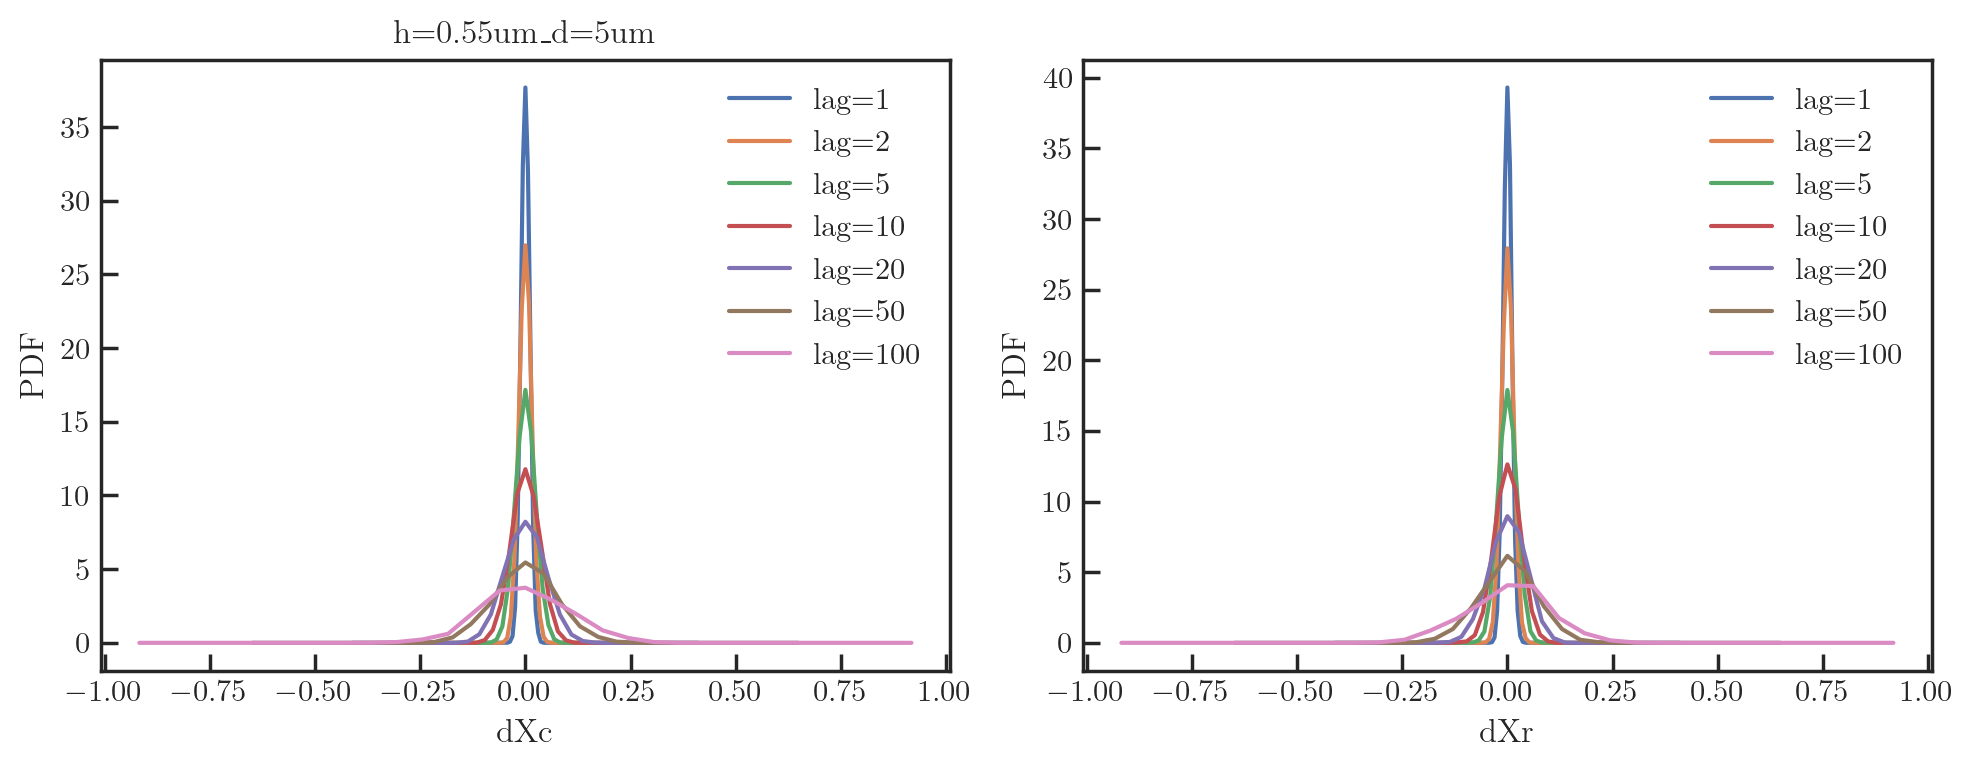

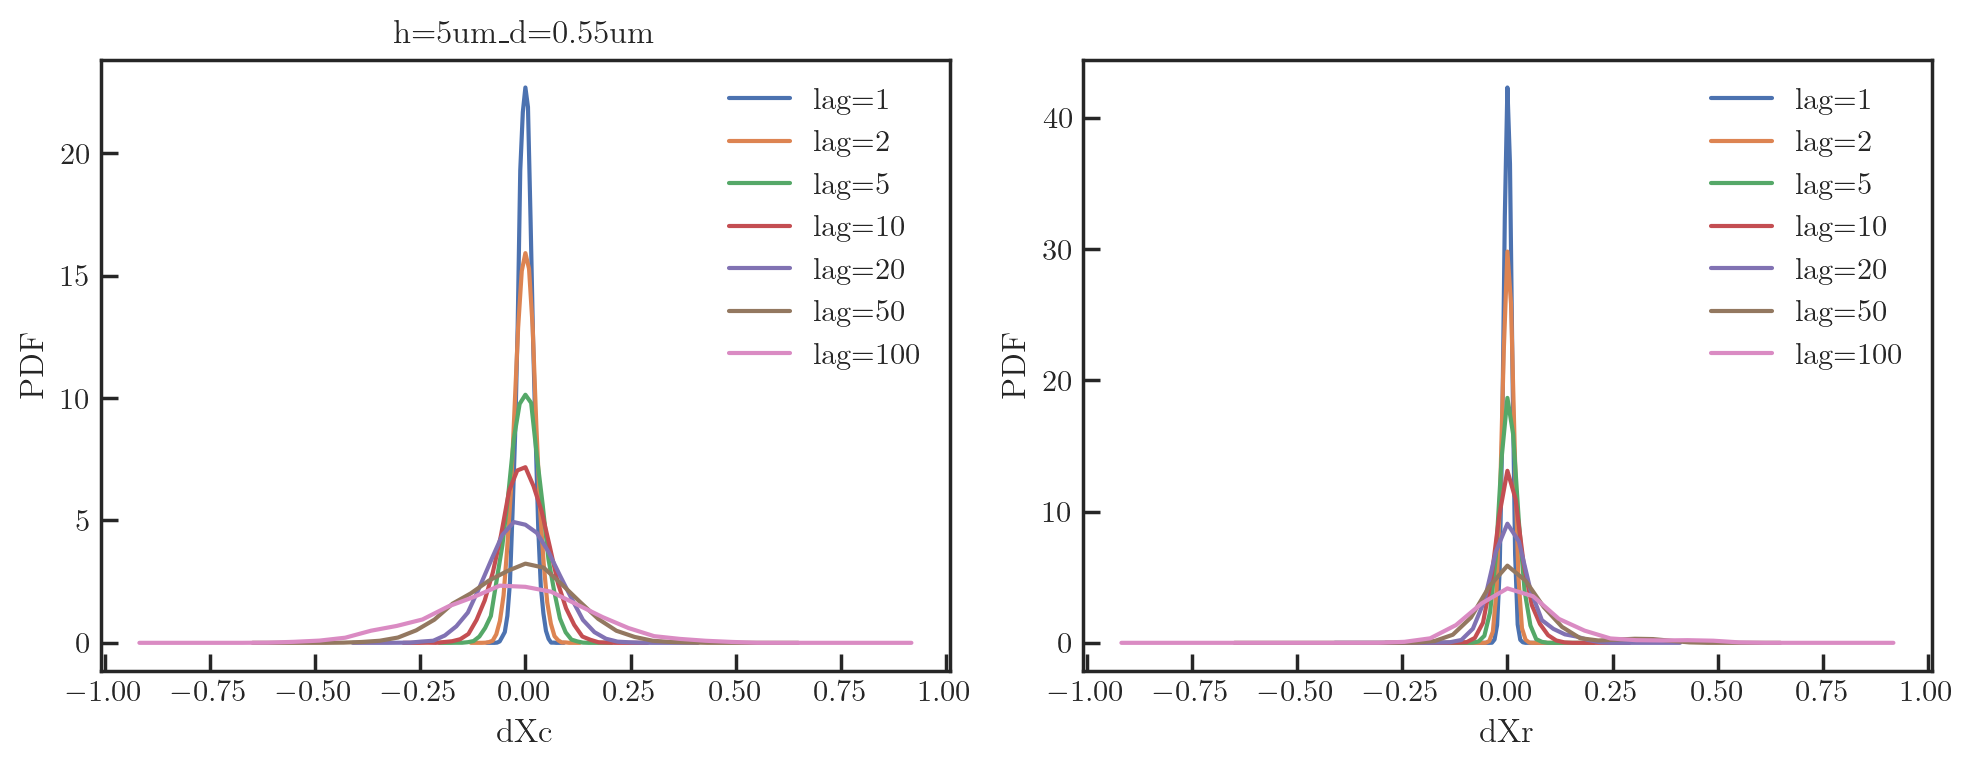

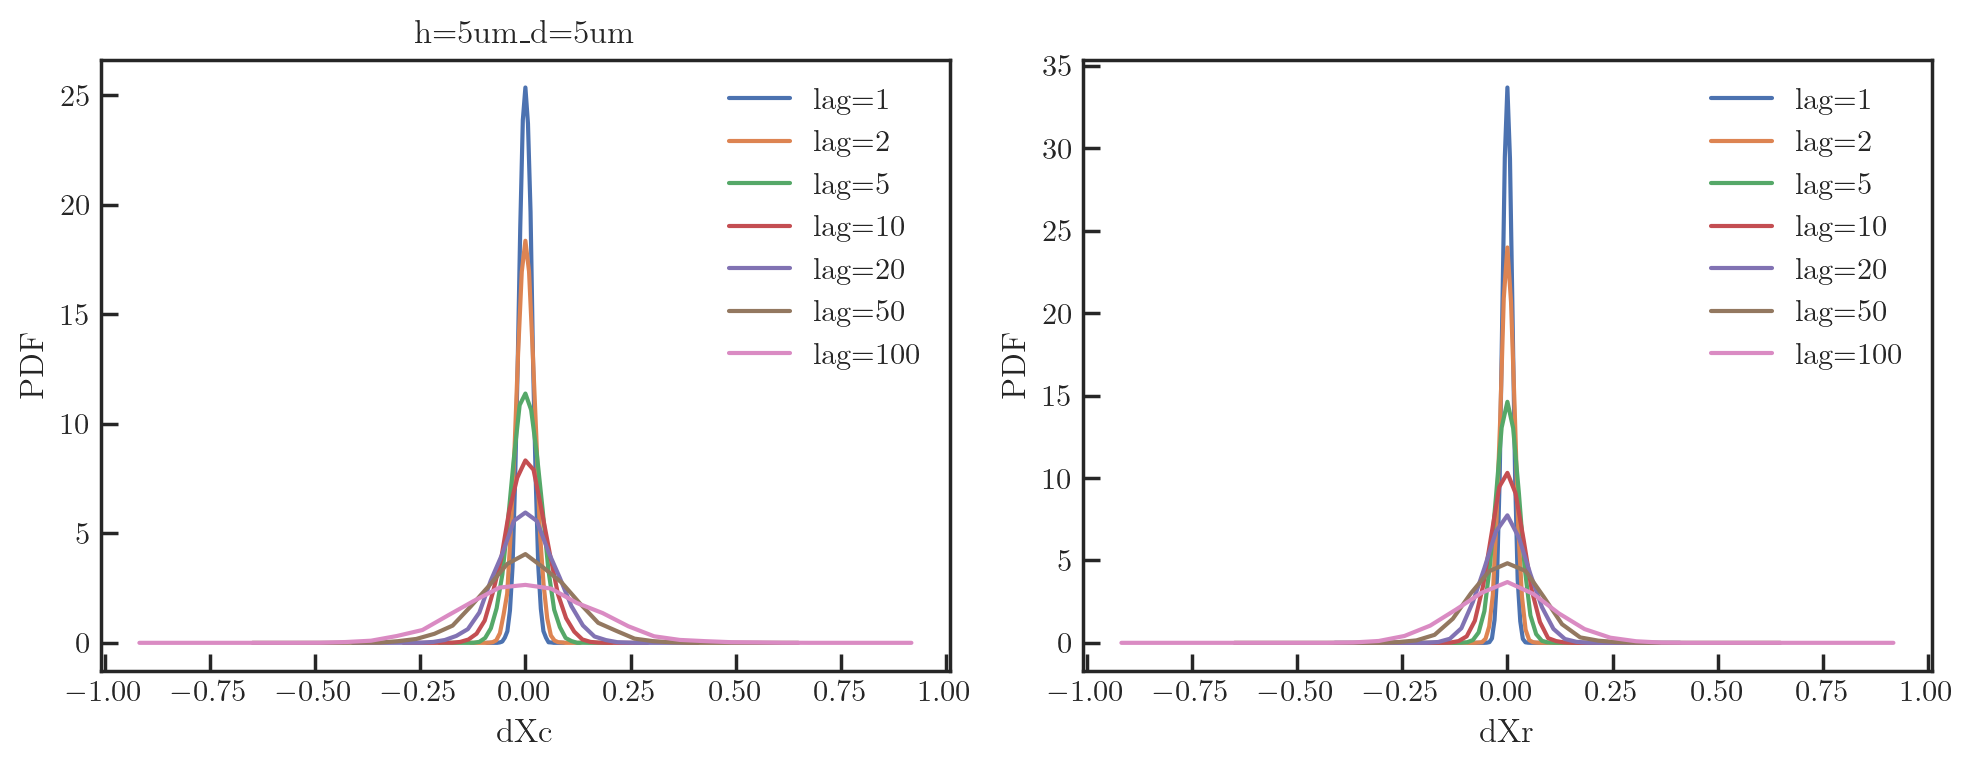

In [ ]:
base_dir = "pairs"
lags_to_plot = lags


def centers(edges):
    return 0.5 * (edges[:-1] + edges[1:])


for case_dir in sorted(Path(base_dir).iterdir()):
    if not case_dir.is_dir():
        continue
    if not (case_dir.name.startswith("h=") and "_d=" in case_dir.name):
        continue

    npz_path = case_dir / "histograms_collective_relative.npz"
    if not npz_path.exists():
        continue

    d = np.load(npz_path)

    lags = d["lags"].astype(int)
    dt = float(d["dt"])

    edges_c = d["edges_collective"]
    edges_r = d["edges_relative"]
    hist_c = d["hist_collective"]
    hist_r = d["hist_relative"]

    fig, (axc, axr) = plt.subplots(1, 2, figsize=(10, 4))

    for lag in lags_to_plot:
        if lag not in lags:
            continue
        i = int(np.where(lags == lag)[0][0])

        axc.plot(centers(edges_c[i]), hist_c[i], label=f"lag={lag}")
        axr.plot(centers(edges_r[i]), hist_r[i], label=f"lag={lag}")

    axc.set_title(f"{case_dir.name}")
    axc.set_xlabel("dXc")
    axc.set_ylabel("PDF")
    axc.legend(frameon=False)

    axr.set_xlabel("dXr")
    axr.set_ylabel("PDF")
    axr.legend(frameon=False)

    plt.tight_layout()
    plt.show()

Amazing work juls !! Now, extract all D coefficients and their bin center and plot that.

In [141]:
import math
import json


# logfit
def fit_log_msd_window(scales, msd, lower_bound_fit, upper_bound_fit):
    scales = np.asarray(scales, dtype=float)
    msd = np.asarray(msd, dtype=float)
    mask = (
        (scales >= lower_bound_fit)
        & (scales <= upper_bound_fit)
        & np.isfinite(msd)
        & (msd > 0)
    )
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan

    x_fit = np.log10(scales[mask])
    y_fit = np.log10(msd[mask])
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    y_pred = slope * x_fit + intercept
    residuals = y_fit - y_pred
    dof = len(x_fit) - 2
    if dof <= 0:
        return slope, intercept, np.nan

    residual_std = np.sqrt(np.sum(residuals**2) / dof)
    denom = np.sqrt(np.sum((x_fit - np.mean(x_fit)) ** 2))
    intercept_std = residual_std / denom if denom > 0 else np.nan
    return slope, intercept, intercept_std


def save_D_per_height_json(results_dict, save_path, json_name="D_per_z.json"):
    """
    results_dict: { height: { 't_min','t_max','slope','intercept','D','stdD' }, ... }
    """
    if not save_path:
        return None
    os.makedirs(save_path, exist_ok=True)

    def _to_native(v):
        if isinstance(v, (np.floating, np.integer)):
            v = v.item()
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            return None
        return v

    out = {}
    for h in sorted(results_dict.keys()):
        vals = results_dict[h]
        out[str(_to_native(h))] = {
            "t_min": _to_native(vals.get("t_min")),
            "t_max": _to_native(vals.get("t_max")),
            "slope": _to_native(vals.get("slope")),
            "intercept": _to_native(vals.get("intercept")),
            "D": _to_native(vals.get("D")),
            "stdD": _to_native(vals.get("stdD")),
        }

    fp = os.path.join(save_path, json_name)
    with open(fp, "w") as jf:
        json.dump(out, jf, indent=2)
    return fp


def diffusion_coeffs_from_binned_msd(
    bin_centers,
    taus_list,
    msd_mean,
    t_min,
    t_max,
    return_arrays=False,
):
    results = {}
    H, Dvals, Derrs, Slopes = [], [], [], []
    tol = 0.02

    for c, taus, mean in zip(np.asarray(bin_centers, dtype=float), taus_list, msd_mean):
        slope, intercept, intercept_std = fit_log_msd_window(taus, mean, t_min, t_max)

        if np.isnan(intercept):
            D = np.nan
            stdD = np.nan
        else:
            D = 10.0**intercept / 2.0
            stdD = (
                (math.log(10) * (10.0**intercept) / 2.0) * intercept_std
                if np.isfinite(intercept_std)
                else np.nan
            )

        if (
            slope <= 1 - tol or slope >= 1 + tol
        ):  # garde fou for non-diffusive regimes to avoid extracting erroneous diffusion coefs
            D = np.nan
            stdD = np.nan

        results[c] = {
            "t_min": float(t_min),
            "t_max": float(t_max),
            "slope": float(slope) if np.isfinite(slope) else np.nan,
            "intercept": float(intercept) if np.isfinite(intercept) else np.nan,
            "D": float(D) if np.isfinite(D) else np.nan,
            "stdD": float(stdD) if np.isfinite(stdD) else np.nan,
        }

        H.append(c)
        Dvals.append(D)
        Derrs.append(stdD)
        Slopes.append(slope)
    print(results)
    if return_arrays:
        return results, np.array(H), np.array(Dvals), np.array(Derrs), np.array(Slopes)
    return results

Plot the MSDs with the fits :

In [142]:
def plot_msd_curves_per_bin(
    bin_centers, taus_list, msd_mean, msd_sem, cmap_name="viridis"
):

    fig, ax = plt.subplots()
    cmap = cm.get_cmap(cmap_name)
    norm = Normalize(vmin=np.min(bin_centers), vmax=np.max(bin_centers))

    for c, taus, mean, sem in zip(bin_centers, taus_list, msd_mean, msd_sem):
        color = cmap(norm(c))
        ax.fill_between(taus, mean - sem, mean + sem, color=color, alpha=0.25)
        ax.plot(taus, mean, color=color, alpha=1)

    ax.set_xlabel("Lag time (s)")
    ax.set_ylabel("MSD")
    ax.set_xlim(1e-4, 5e-3)
    # ax.set_ylim(6e-4, 6e-3)

    ax.set_xscale("log")
    ax.set_yscale("log")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("z (um)")

    return fig, ax


def do_fit_MSD(bin_centers, taus_list, msd_mean, t_min, t_max, save_json_path):
    fit_results = diffusion_coeffs_from_binned_msd(
        bin_centers, taus_list, msd_mean, t_min=t_min, t_max=t_max, return_arrays=False
    )

    os.makedirs(os.path.dirname(save_json_path), exist_ok=True)
    save_D_per_height_json(
        fit_results,
        os.path.dirname(save_json_path),
        json_name=os.path.basename(save_json_path),
    )
    return fit_results

In [143]:
def plot_diffusion_multiple_phi(json_name="D_per_height.json"):
    plt.figure(figsize=(8, 4))

    results = []
    for shear_dir in os.listdir("."):
        if os.path.isdir(shear_dir) and shear_dir.startswith("shear="):
            shear_match = re.search(r"shear=([0-9.+-eE]+)", shear_dir)
            if not shear_match:
                continue
            shear_val = float(shear_match.group(1))

            for phi_dir in os.listdir(shear_dir):
                phi_path = os.path.join(shear_dir, phi_dir)
                if os.path.isdir(phi_path) and phi_dir.startswith("phi="):
                    phi_match = re.search(r"phi=([0-9.+-eE]+)", phi_dir)
                    if not phi_match:
                        continue

                    phi_val = float(phi_match.group(1))

                    json_path = os.path.join(phi_path, json_name)
                    if not os.path.exists(json_path):
                        continue

                    with open(json_path, "r") as f:
                        data = json.load(f)

                    z = sorted(map(float, data.keys()))
                    D = [
                        np.nan if data[str(key)]["D"] is None else data[str(key)]["D"]
                        for key in z
                    ]

                    stdD = [
                        (
                            np.nan
                            if data[str(key)]["stdD"] is None
                            else data[str(key)]["stdD"]
                        )
                        for key in z
                    ]

                    results.append(
                        {
                            "shear": shear_val,
                            "phi": phi_val,
                            "z": z,
                            "D": D,
                            "stdD": stdD,
                        }
                    )

    phi_vals = np.array([r["phi"] for r in results])
    norm = LogNorm(vmin=min(phi_vals), vmax=max(phi_vals))
    cmap = plt.get_cmap("viridis")

    shear_vals = sorted(set(r["shear"] for r in results))
    markers = ["o", "s", "^"]
    marker_map = {s: markers[i % len(markers)] for i, s in enumerate(shear_vals)}

    for r in results:
        color = cmap(norm(r["phi"]))
        marker = marker_map[r["shear"]]
        label = f"$\phi={r['phi']}, \dot\gamma$={r['shear']}"
        plt.errorbar(
            r["z"][:],
            r["D"][:],
            yerr=r["stdD"][:],
            fmt=marker,
            color=color,
            capsize=3,
            label=label,
            alpha=0.5,
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label(r"$\phi$ value")

    plt.xlabel(r"$z\;(\mu \mathrm{m})$")
    plt.ylabel(r"$D_y\;(\mu \mathrm{m}^2\,\mathrm{s}^{-1})$")
    plt.ylim(0, 5)
    plt.legend(frameon=False, fontsize=8, loc="lower right", ncols=2)
    plt.tight_layout()
    plt.savefig("Dyfz_colormap.pdf", transparent=True)
    plt.show()


def plot_D_curves_per_bin(
    bin_centers, taus_list, msd_mean, msd_sem, cmap_name="viridis"
):

    bin_centers = bin_centers / 0.055

    fig, ax = plt.subplots()
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(bin_centers), vmax=np.max(bin_centers))

    Dmean = [m / (2 * t) for m, t in zip(msd_mean, taus_list)]
    Dsem = [m / (2 * t) for m, t in zip(msd_sem, taus_list)]
    for c, taus, mean, sem in zip(bin_centers, taus_list, Dmean, Dsem):
        color = cmap(norm(c))
        ax.fill_between(taus, mean - sem, mean + sem, color=color, alpha=0.25)
        ax.plot(taus, mean, color=color, alpha=1)

    ax.set_xlabel(r"$\tau (s)$")
    ax.set_ylabel(r"MSD$/\tau (\mu \mathrm{m}^2.\mathrm{s}^{-1})$")
    ax.set_xlim(1e-4, 1e-2)
    ax.set_ylim(2, 5)

    ax.set_xscale("log")
    ax.set_yscale("log")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("$z/r$")

    return fig, ax

<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\d'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_27358/431589189.py:64: SyntaxWarning: invalid escape sequence '\p'
  label = f"$\phi={r['phi']}, \dot\gamma$={r['shear']}"
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_27358/431589189.py:64: SyntaxWarning: invalid escape sequence '\d'
  label = f"$\phi={r['phi']}, \dot\gamma$={r['shear']}"


# Batch treating all phi dirs withing shear dirs

In [144]:
import parameters

t_min = parameters.time_step
dt = parameters.time_step

t_max = 1e-3
z_threshold = 2.0  # parameters.evanescent_slice_z_height * parameters.m_to_um

for nameshear in np.sort(os.listdir(".")):
    if os.path.isdir(nameshear) and nameshear.startswith("shear="):

        for namephi in os.listdir(nameshear):
            phi_path = os.path.join(nameshear, namephi)

            if os.path.isdir(phi_path) and namephi.startswith("phi="):

                folder = f"{nameshear}/{namephi}"
                out_json = f"/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/{folder}/D_per_height.json"

                # Skip if the exact output file already exists
                # if os.path.exists(out_json):
                #     print(f"Skipping {folder}: D_per_height.json already exists.")
                #     continue

                config = f"/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/{folder}/run_blobs.sphere_array.config"
                frames, num_particles = parse_config(config)
                trajs = frames_to_trajectories(frames)
                segments_per_particle = split_by_z_threshold(
                    trajs, z_threshold=z_threshold, inclusive=True, min_len=10
                )

                signals = [seg for parts in segments_per_particle for seg in parts]

                # signals = [] ### possible to concatenate everythin with the line above !
                # for parts in segments_per_particle:
                # for seg in parts:
                # signals.append(seg)

                bins, edges = identify_trajectories_per_avg_height(
                    signals,
                    debye_height=0.1,
                    evanescent_height=z_threshold,
                    how_many_bins=12,
                )

                bin_centers, taus_list, msd_mean, msd_sem = average_msd_per_bin(
                    bins=bins, bin_edges=edges, comp="y", dt=dt
                )

                do_fit_MSD(
                    bin_centers,
                    taus_list,
                    msd_mean,
                    t_min=t_min,
                    t_max=t_max,
                    save_json_path=out_json,
                )

                print(
                    do_fit_MSD(
                        bin_centers,
                        taus_list,
                        msd_mean,
                        t_min=t_min,
                        t_max=t_max,
                        save_json_path=out_json,
                    )
                )

                plot_msd_curves_per_bin(
                    bin_centers, taus_list, msd_mean, msd_sem, cmap_name="viridis"
                )

ModuleNotFoundError: No module named 'parameters'

# Plotting D(y=inf) = f(tau)

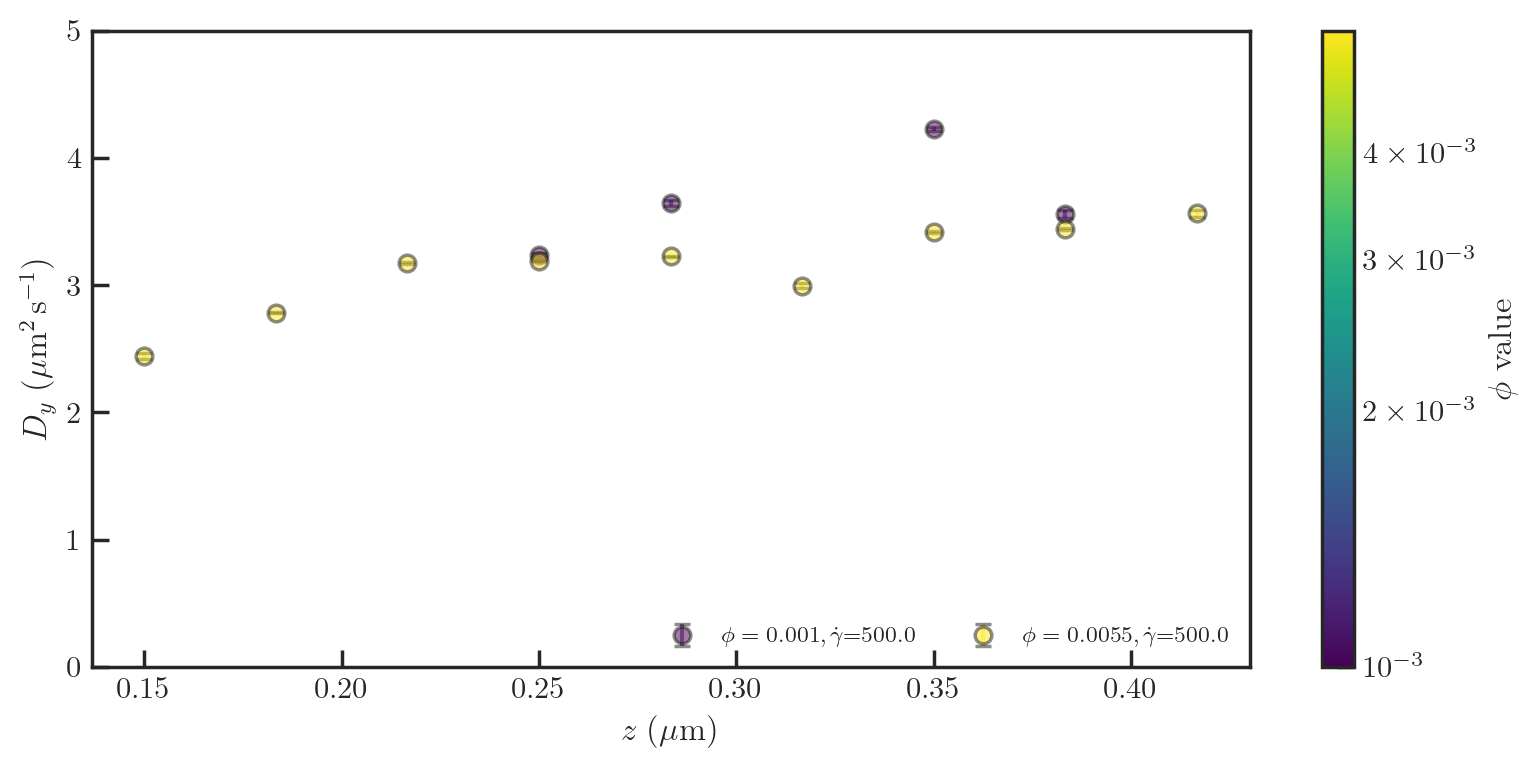

In [ ]:
plot_diffusion_multiple_phi("D_per_height.json")

# MSD plots now turned into D plots as Dy = f(z, t)

comp = "y"
dt = 1e-4
t_min, t_max = dt, 1e-1

tmax_array = np.linspace(10 * t_min, t_max, 5)

z_threshold = .5



for name in np.sort(os.listdir(".")):
    if os.path.isdir(name) and name.startswith("phi="):
        for t in tmax_array :
            config = f"/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/{name}/run_blobs.sphere_array.config" 
            frames, num_particles = parse_config(config) 
            trajs = frames_to_trajectories(frames)
            segments_per_particle = split_by_z_threshold(trajs, z_threshold=z_threshold, inclusive=True, min_len=10) 



            signals = [seg for parts in segments_per_particle for seg in parts]


            bins, edges = identify_trajectories_per_avg_height(
                signals, debye_height=.1, evanescent_height=z_threshold, how_many_bins=12 
            )

            bin_centers, taus_list, msd_mean, msd_sem = average_msd_per_bin(
                bins=bins, bin_edges=edges, comp=comp, dt=dt,
            )

            do_fit_MSD(bin_centers, taus_list, msd_mean, t_min=t_min, t_max=t, save_json_path=f"./{name}/D_per_height_tmax={t}.json")





fig, ax = plot_msd_curves_per_bin(
bin_centers, taus_list, msd_mean, msd_sem,
cmap_name="viridis"
)
            
fig, ax = plot_D_curves_per_bin(
bin_centers[1:], taus_list[1:], msd_mean[1:], msd_sem[1:],
cmap_name="viridis"
)

In [ ]:
import json
import numpy as np
import os

tmax_vals = []
D_vals = []
std_vals = []

for name in np.sort(os.listdir(".")):
    if os.path.isdir(name) and name.startswith("phi="):
        for Dfile in np.sort(os.listdir(f"./{name}")):
            if Dfile.startswith("D_per_height"):
                filepath = os.path.join(name, Dfile)
                with open(filepath, "r") as f:
                    data = json.load(f)

                keys = sorted(data.keys(), key=float)
                penultimate_key = keys[-2]
                penultimate_bin = data[penultimate_key]

                D = penultimate_bin["D"]
                std = penultimate_bin["stdD"]

                tmax_str = Dfile.split("tmax=")[1].split(".json")[0]
                tmax = float(tmax_str)

                tmax_vals.append(tmax)
                D_vals.append(D)
                std_vals.append(std)

tmax_vals = np.array(tmax_vals)
D_vals = np.array(D_vals)
std_vals = np.array(std_vals)

order = np.argsort(tmax_vals)
tmax_vals = tmax_vals[order]
D_vals = D_vals[order]
std_vals = std_vals[order]

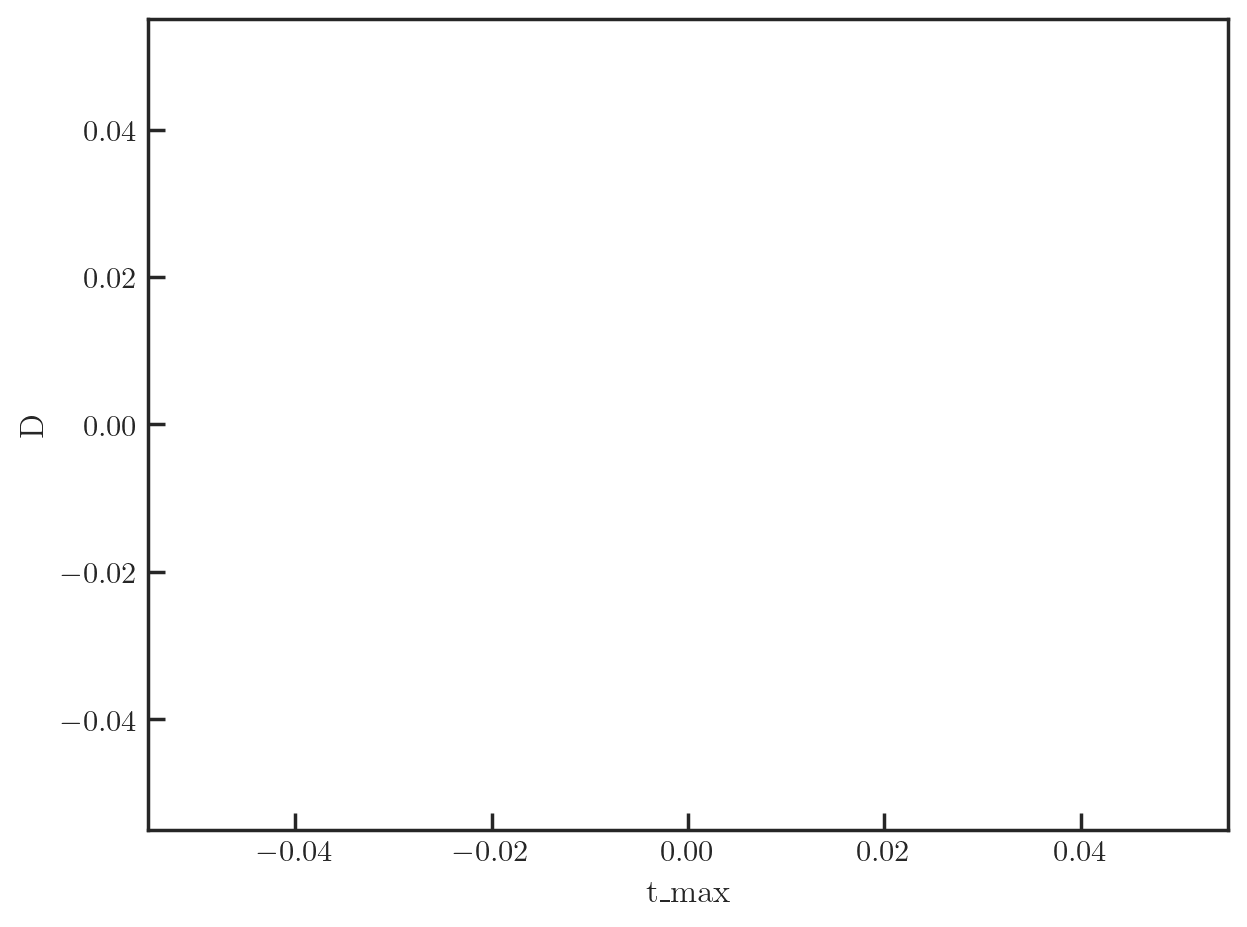

In [ ]:
plt.errorbar(tmax_vals, D_vals, yerr=std_vals, fmt="o")
plt.xlabel("t_max")
plt.ylabel("D")
plt.tight_layout()
plt.show()